In [4]:
import pandas as pd
import glob
import os
import csv
from io import StringIO

# Folder containing Giovanni rainfall files
folder = r"D:\NERDRR\July 2026\Kamrup Mtro Flood\GPM,"

files = glob.glob(os.path.join(folder, "*.csv"))

print(f"Found {len(files)} files.\n")

for file in files:

    print("="*80)
    print("Processing:", os.path.basename(file))

    # ---------------------------------------------------
    # Read file
    # ---------------------------------------------------
    with open(file, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # ---------------------------------------------------
    # Find where the table starts
    # ---------------------------------------------------
    start = None
    for i, line in enumerate(lines):
        if line.strip().lower().startswith("time"):
            start = i
            break

    if start is None:
        print("No data table found.")
        continue

    # Extract only the table
    table = "".join(lines[start:])

    # ---------------------------------------------------
    # Automatically detect delimiter
    # ---------------------------------------------------
    sample = table.split("\n")[0]

    try:
        dialect = csv.Sniffer().sniff(sample)
        sep = dialect.delimiter
    except:
        sep = None

    print("Detected delimiter:", repr(sep))

    if sep is not None:
        df = pd.read_csv(StringIO(table), sep=sep)
    else:
        df = pd.read_csv(StringIO(table), sep=r"\s+", engine="python")

    print("Columns:", list(df.columns))

    # Remove spaces from column names
    df.columns = df.columns.str.strip()

    # ---------------------------------------------------
    # If only one column exists, split manually
    # ---------------------------------------------------
    if len(df.columns) == 1:

        print("Single column detected. Splitting manually...")

        df = df.iloc[:,0].str.split(r"\s{2,}|\t|,", expand=True)

    print(df.head())

    if df.shape[1] < 2:
        print("Could not detect rainfall column.")
        continue

    # Rename
    df = df.iloc[:,0:2]
    df.columns = ["time","rain_rate"]

    # Remove repeated header row if present
    df = df[df["time"]!="time"]

    # Convert rainfall
    df["rain_rate"] = pd.to_numeric(df["rain_rate"], errors="coerce")

    df = df.dropna()

    df = df[df["rain_rate"]!=-9999.9]

    # ---------------------------------------------------
    # Parse dates automatically
    # ---------------------------------------------------
    df["time"] = pd.to_datetime(
        df["time"],
        format="mixed",
        dayfirst=True,
        errors="coerce"
    )

    df = df.dropna(subset=["time"])

    # ---------------------------------------------------
    # Convert mm/hr → mm/30min
    # ---------------------------------------------------
    df["Rainfall_mm"] = df["rain_rate"] * 0.5

    # Daily rainfall
    df["Date"] = df["time"].dt.date

    daily = (
        df.groupby("Date")["Rainfall_mm"]
        .sum()
        .reset_index()
    )

    daily.rename(columns={"Rainfall_mm":"Daily_Rainfall_mm"}, inplace=True)

    print(daily)

    # Save
    outfile = os.path.join(
        folder,
        os.path.splitext(os.path.basename(file))[0] +
        "_DailyRainfall.csv"
    )

    daily.to_csv(outfile,index=False)

    print("Saved:", outfile)

print("\nAll files completed.")

Found 1 files.

Processing: g4.areaAvgTimeSeries.GPM_3IMERGHHL_07_precipitation.20260705-20260712.91E_25N_92E_26N.csv
Detected delimiter: ','
Columns: ['time', ' mean_GPM_3IMERGHHL_07_precipitation']
                  time  mean_GPM_3IMERGHHL_07_precipitation
0  2026-07-05 00:00:00                             0.051650
1  2026-07-05 00:30:00                             0.085009
2  2026-07-05 01:00:00                             0.123345
3  2026-07-05 01:30:00                             0.120008
4  2026-07-05 02:00:00                             0.104452
         Date  Daily_Rainfall_mm
0  2026-05-07           1.577271
1  2026-06-07          20.698876
2  2026-07-07          17.893185
3  2026-08-07          20.740164
4  2026-09-07          13.515772
5  2026-10-07          11.784467
6  2026-11-07          36.936894
7  2026-12-07          16.716383
Saved: D:\NERDRR\July 2026\Kamrup Mtro Flood\GPM,\g4.areaAvgTimeSeries.GPM_3IMERGHHL_07_precipitation.20260705-20260712.91E_25N_92E_26N_DailyRa

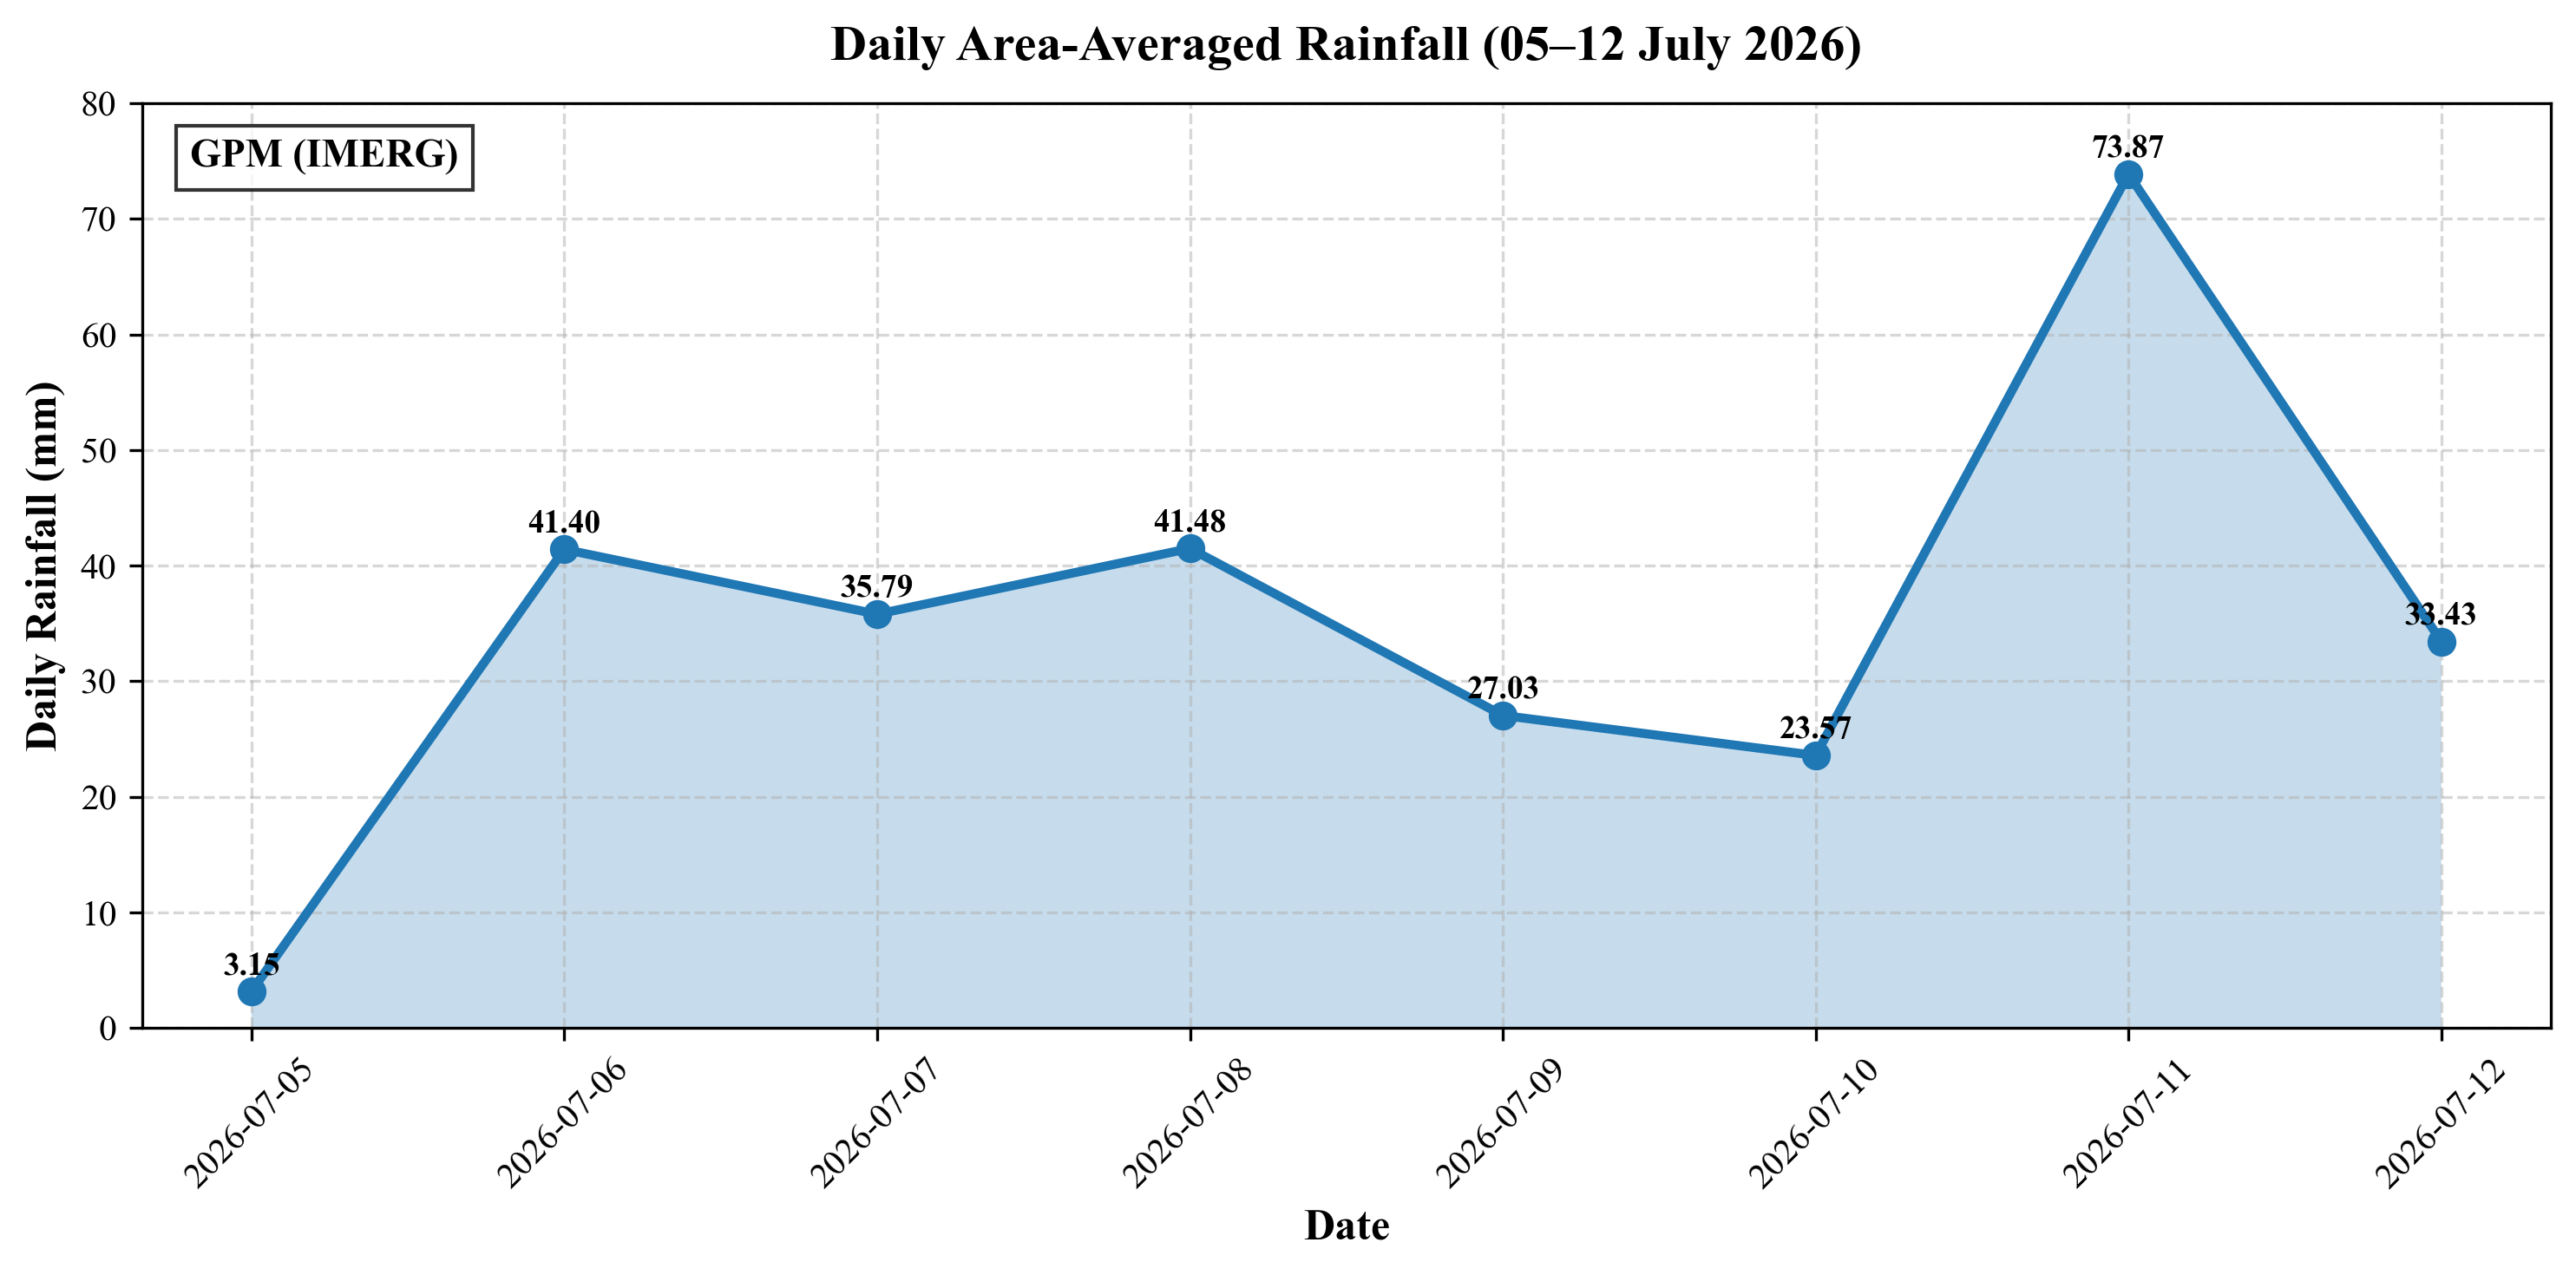

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# Daily IMERG Rainfall Data
# =====================================================

data = {
    "Date": [
        "05-Jul-26", "06-Jul-26", "07-Jul-26", "08-Jul-26",
        "09-Jul-26", "10-Jul-26", "11-Jul-26", "12-Jul-26"
    ],
    "Daily Rainfall (mm)": [
        3.15, 41.40, 35.79, 41.48,
        27.03, 23.57, 73.87, 33.43
    ]
}

df = pd.DataFrame(data)
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

# =====================================================
# Plot
# =====================================================

plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

ax.plot(
    df["Date"],
    df["Daily Rainfall (mm)"],
    marker="o",
    linewidth=2.5,
    markersize=7
)

# Fill below line
ax.fill_between(
    df["Date"],
    df["Daily Rainfall (mm)"],
    alpha=0.25
)

# Annotate rainfall values
for x, y in zip(df["Date"], df["Daily Rainfall (mm)"]):
    ax.text(
        x,
        y + 1.5,
        f"{y:.2f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# =====================================================
# Labels
# =====================================================

ax.set_xlabel(
    "Date",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Daily Rainfall (mm)",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Daily Area-Averaged Rainfall (05–12 July 2026)",
    fontsize=14,
    fontweight="bold",
    pad=12
)

# =====================================================
# IMERG Label
# =====================================================

ax.text(
    0.02,
    0.96,
    "GPM (IMERG)",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

# =====================================================
# Formatting
# =====================================================

ax.grid(True, linestyle="--", alpha=0.5)

ax.set_ylim(0, 80)

plt.xticks(rotation=45)

plt.tight_layout()

# Save Figure
plt.savefig(
    "GPM IMERG_Daily_Rainfall_July2026_1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======================================================
# Folder containing daily rainfall CSV files
# ======================================================
input_folder = r"Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily"

output_folder = os.path.join(input_folder, "Plots")
os.makedirs(output_folder, exist_ok=True)

# ======================================================
# Read all csv files
# ======================================================
csv_files = glob.glob(os.path.join(input_folder, "*.csv"))

print(f"Found {len(csv_files)} files.\n")

for file in csv_files:

    print("=" * 80)
    print("Processing:", os.path.basename(file))

    # --------------------------------------------------
    # Read CSV
    # --------------------------------------------------
    df = pd.read_csv(file)

    # Remove extra spaces from column names
    df.columns = df.columns.str.strip()

    # Check required columns
    if "Date" not in df.columns or "Daily_Rainfall_mm" not in df.columns:
        print("Required columns not found.")
        continue

    # --------------------------------------------------
    # Convert rainfall to numeric
    # --------------------------------------------------
    df["Daily_Rainfall_mm"] = pd.to_numeric(
        df["Daily_Rainfall_mm"],
        errors="coerce"
    )

    # --------------------------------------------------
    # Convert date (handles mixed formats)
    # --------------------------------------------------
    df["Date"] = pd.to_datetime(
        df["Date"].astype(str).str.strip(),
        format="mixed",
        dayfirst=True,
        errors="coerce"
    )

    # Remove invalid rows
    df = df.dropna(subset=["Date", "Daily_Rainfall_mm"])

    # Sort by date
    df = df.sort_values("Date")

    # --------------------------------------------------
    # District name
    # --------------------------------------------------
    district = os.path.splitext(os.path.basename(file))[0]
    district = district.replace("_DailyRainfall", "")

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    plt.figure(figsize=(15,6))

    plt.bar(
        df["Date"],
        df["Daily_Rainfall_mm"],
        color="dodgerblue",
        edgecolor="navy",
        linewidth=0.6,
        width=0.8,
        label="Daily Rainfall"
    )

    plt.plot(
        df["Date"],
        df["Daily_Rainfall_mm"],
        color="darkred",
        marker="o",
        linewidth=2,
        markersize=5
    )

    plt.title(
        f"Daily Rainfall\n{district}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Rainfall (mm/day)", fontsize=14)

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    ax = plt.gca()

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%d-%b")
    )

    plt.xticks(rotation=45)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.legend()

    plt.tight_layout()

    outfile = os.path.join(
        output_folder,
        district + "_Rainfall.png"
    )

    plt.savefig(
        outfile,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print("Saved:", outfile)

print("\n========================================")
print("All rainfall plots generated successfully.")
print("Output Folder:", output_folder)

Found 6 files.

Processing: east garo hills 26may 03june_DailyRainfall.csv
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\east garo hills 26may 03june_Rainfall.png
Processing: north garo hills 5 6 oct24_DailyRainfall.csv
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\north garo hills 5 6 oct24_Rainfall.png
Processing: saoth garo hills_4oct_DailyRainfall.csv
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\saoth garo hills_4oct_Rainfall.png
Processing: South West Garo Hills 20May_DailyRainfall.csv
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\South West Garo Hills 20May_Rainfall.png
Processing: West Garo Hills 20May_DailyRainfall.csv
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\West Garo Hills 20May_Rainfall.png
Processing: West Garo Hills Oct_DailyRainfall.csv
Saved: Y:\NERDRR\T

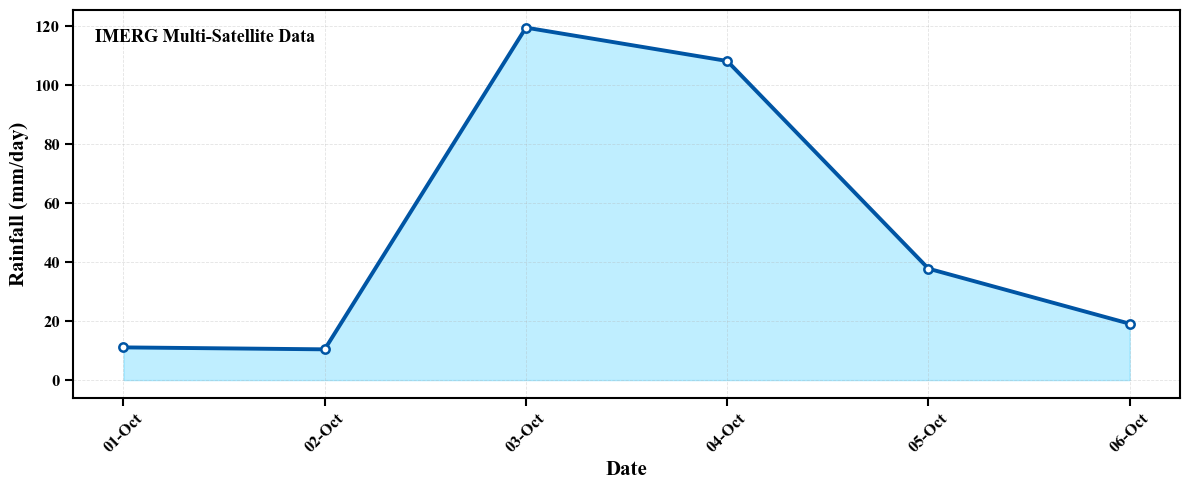

In [7]:
# ==================================================
# Plot
# ==================================================

fig, ax = plt.subplots(figsize=(12,5))

# Area
ax.fill_between(
    df["Date"],
    df["Daily_Rainfall_mm"],
    color="deepskyblue",
    alpha=0.25
)

# Line
ax.plot(
    df["Date"],
    df["Daily_Rainfall_mm"],
    color="#0055A4",
    linewidth=2.8,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=1.8
)

# -------------------------
# Axis Labels
# -------------------------
ax.set_xlabel(
    "Date",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel(
    "Rainfall (mm/day)",
    fontsize=15,
    fontweight="bold"
)

# -------------------------
# Text inside graph
# -------------------------
ax.text(
    0.02,
    0.95,
    "IMERG Multi-Satellite Data",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top",
    color="black"
)

# -------------------------
# Date formatting
# -------------------------
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)

# -------------------------
# Grid
# -------------------------
ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

# -------------------------
# Full Border
# -------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

# -------------------------
# Bold Tick Labels
# -------------------------
ax.tick_params(
    axis="both",
    labelsize=12,
    width=1.5,
    length=6
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()

In [11]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======================================================
# Input and Output folders
# ======================================================
input_folder = r"Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily"

output_folder = os.path.join(input_folder, "Plots")
os.makedirs(output_folder, exist_ok=True)

# ======================================================
# Publication Style
# ======================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# ======================================================
# Read all CSV files
# ======================================================
csv_files = glob.glob(os.path.join(input_folder, "*.csv"))

print(f"Found {len(csv_files)} files.\n")

for file in csv_files:

    # --------------------------------------------------
    # Read data
    # --------------------------------------------------
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    df["Date"] = pd.to_datetime(
        df["Date"].astype(str).str.strip(),
        format="mixed",
        dayfirst=True,
        errors="coerce"
    )

    df["Daily_Rainfall_mm"] = pd.to_numeric(
        df["Daily_Rainfall_mm"],
        errors="coerce"
    )

    df = df.dropna(subset=["Date", "Daily_Rainfall_mm"])
    df = df.sort_values("Date")

    district = os.path.splitext(os.path.basename(file))[0]
    district = district.replace("_DailyRainfall", "")

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 4.8))

    ax.plot(
        df["Date"],
        df["Daily_Rainfall_mm"],
        color="red",
        linewidth=2.2,
        marker="o",
        markersize=6,
        markerfacecolor="red",
        markeredgecolor="black",
        markeredgewidth=0.8
    )

    # --------------------------------------------------
    # Display rainfall value
    # --------------------------------------------------
    offset = df["Daily_Rainfall_mm"].max() * 0.03

    for x, y in zip(df["Date"], df["Daily_Rainfall_mm"]):
        ax.text(
            x,
            y + offset,
            f"{y:.1f}",
            fontsize=9,
            ha="center",
            va="bottom"
        )

    # --------------------------------------------------
    # Source Label (Top Left)
    # --------------------------------------------------
    ax.text(
        0.02,
        0.97,
        "GPM (IMERG)",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="top"
    )

    # --------------------------------------------------
    # Axis Labels
    # --------------------------------------------------
    ax.set_xlabel("Date", fontsize=13, fontweight="bold")
    ax.set_ylabel("Daily Rainfall (mm)", fontsize=13, fontweight="bold")

    # --------------------------------------------------
    # Date Format
    # --------------------------------------------------
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    fig.autofmt_xdate(rotation=45)

    # --------------------------------------------------
    # Grid
    # --------------------------------------------------
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

    # --------------------------------------------------
    # FULL RECTANGULAR BORDER
    # --------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color("black")

    # --------------------------------------------------
    # Tick Style
    # --------------------------------------------------
    ax.tick_params(
        axis='both',
        which='major',
        direction='out',
        length=6,
        width=1.2,
        labelsize=11
    )

    # Small margin above highest value
    ax.set_ylim(
        0,
        df["Daily_Rainfall_mm"].max() * 1.20
    )

    plt.tight_layout()

    # --------------------------------------------------
    # Save Figure
    # --------------------------------------------------
    outfile = os.path.join(output_folder, district + "_Rainfall_Line.png")
    plt.savefig(
        outfile,
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close()

    print(f"Saved: {outfile}")

print("\nAll plots generated successfully.")

Found 6 files.

Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\east garo hills 26may 03june_Rainfall_Line.png
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\north garo hills 5 6 oct24_Rainfall_Line.png
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\saoth garo hills_4oct_Rainfall_Line.png
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\South West Garo Hills 20May_Rainfall_Line.png
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\West Garo Hills 20May_Rainfall_Line.png
Saved: Y:\NERDRR\Team_NERDRR_2026\July 2026\Meghalaya flood\rainfall\Raifall Daily\Plots\West Garo Hills Oct_Rainfall_Line.png

All plots generated successfully.


In [ ]:
import geopandas as gpd
import pandas as pd

# ============================================================
# Input Files
# ============================================================

lulc_file = r"D:\NERDRR\July 2026\Kamrup Mtro Flood\Flood Layers\lulc.shp"
flood_file = r"D:\NERDRR\July 2026\Kamrup Mtro Flood\Flood Layers\InundationArea_Final.shp"

# Output
output_excel = r"D:\NERDRR\July 2026\Kamrup Mtro Flood\Flood Layers\LULC_Flood_Statistics_final.xlsx"

# LULC class field
lulc_field = "DSCR1"

# ============================================================
# Read Files
# ============================================================

lulc = gpd.read_file(lulc_file)
flood = gpd.read_file(flood_file)

# ============================================================
# Check CRS
# ============================================================

if lulc.crs != flood.crs:
    flood = flood.to_crs(lulc.crs)

# IMPORTANT:
# Use projected CRS (meters), NOT EPSG:4326
if lulc.crs.is_geographic:
    raise ValueError(
        "Your shapefile is in Geographic CRS (Latitude/Longitude).\n"
        "Please reproject to UTM or another projected CRS before area calculation."
    )

# ============================================================
# Calculate Total Area
# ============================================================

lulc["Total_Area_ha"] = lulc.geometry.area / 10000

total_area = (
    lulc.groupby(lulc_field)["Total_Area_ha"]
    .sum()
    .reset_index()
)

# ============================================================
# Intersect Flood with LULC
# ============================================================

intersection = gpd.overlay(
    lulc[[lulc_field, "geometry"]],
    flood[["geometry"]],
    how="intersection"
)

intersection["Flood_Area_ha"] = (
    intersection.geometry.area / 10000
)

flood_area = (
    intersection.groupby(lulc_field)["Flood_Area_ha"]
    .sum()
    .reset_index()
)

# ============================================================
# Merge Results
# ============================================================

result = total_area.merge(
    flood_area,
    on=lulc_field,
    how="left"
)

result["Flood_Area_ha"] = result["Flood_Area_ha"].fillna(0)

result["Flood_Percentage"] = (
    result["Flood_Area_ha"]
    / result["Total_Area_ha"]
) * 100

result = result.rename(columns={
    lulc_field: "LULC_Class"
})

result = result.sort_values("Flood_Percentage", ascending=False)

# ============================================================
# Round Values
# ============================================================

result["Total_Area_ha"] = result["Total_Area_ha"].round(2)
result["Flood_Area_ha"] = result["Flood_Area_ha"].round(2)
result["Flood_Percentage"] = result["Flood_Percentage"].round(2)

# ============================================================
# Save
# ============================================================

result.to_excel(output_excel, index=False)

print(result)

print("\nSaved:", output_excel)

                 LULC_Class  Total_Area_ha  Flood_Area_ha  Flood_Percentage
0         Agricultural Land       30479.12        3975.07             13.04
3  Grassland / Grazing land        3094.66         149.04              4.82
6              Water bodies        7198.32         149.81              2.08
5                Wastelands        5044.41          99.36              1.97
1                  Built Up       11882.73         186.04              1.57
2                    Forest       44854.40          26.52              0.06
4      Shifting Cultivation          21.80           0.00              0.00

Saved: D:\NERDRR\July 2026\Kamrup Mtro Flood\Flood Layers\LULC_Flood_Statistics.xlsx
